In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
df = pd.read_csv("results/csv-files/scenarios_evaluated.csv")

- 0: Incorrect Scenario Group
    - Incorrect Scenario, Incorrect Transaction 
    - Incorrect Scenario, Correct Transaction
    - Incorrect Scenario, Incomplete Transaction
- 1: Correct Scenario Group
    - Correct Scenario, Incorrect Transaction 
    - Correct Scenario, Correct Transaction
    - Correct Scenario, Incomplete Transaction
- 2: Missing Scenario Group 
    - Missing Scenario, Missing Transaction
- 3: Incomplete Scenario Group
    - Incomplete Scenario, Incorrect Transaction 
    - Incomplete Scenario, Correct Transaction
    - Incomplete Scenario, Missing Transaction
    - Incomplete Scenario, Incomplete Transaction


In [21]:
round(df["Scenario_Error"].value_counts()/len(df),4)

Scenario_Error
missing scenario        0.3367
unspecified accounts    0.2833
incorrect scenario      0.1433
correct                 0.1167
missing effect          0.0633
incorrect effect        0.0567
Name: count, dtype: float64

In [16]:
models = ["CodeL", "CodeQ", "Mistral", "Llama", "Qwen"]

for model in models:
    print(f"Distribution of Scenario Errors for {model}:")
    print(round(df[df["ID"].str.contains(model)]["Scenario_Error"].value_counts()/len(df),4),"\n--------------------------------")

Distribution of Scenario Errors for CodeL:
Scenario_Error_Type
missing scenario    0.1367
missing effect      0.0633
Name: count, dtype: float64 
--------------------------------
Distribution of Scenario Errors for CodeQ:
Scenario_Error_Type
missing scenario    0.2
Name: count, dtype: float64 
--------------------------------
Distribution of Scenario Errors for Mistral:
Scenario_Error_Type
unspecified accounts    0.1167
incorrect scenario      0.0433
correct                 0.0400
Name: count, dtype: float64 
--------------------------------
Distribution of Scenario Errors for Llama:
Scenario_Error_Type
unspecified accounts    0.1033
incorrect scenario      0.0467
correct                 0.0333
incorrect effect        0.0167
Name: count, dtype: float64 
--------------------------------
Distribution of Scenario Errors for Qwen:
Scenario_Error_Type
unspecified accounts    0.0633
incorrect scenario      0.0533
correct                 0.0433
incorrect effect        0.0400
Name: count, dtyp

In [26]:
def transaction_error_classification(df):
    balance_count = df['Transaction_Error'].str.contains('Transaction does not balance', na=False).sum()
    invalid_unknown_count = df['Transaction_Error'].str.contains('Invalid reference to unknown account', na=False).sum()
    missing_count = df['Transaction_Error'].str.contains('Missing Transaction', na=False).sum()
    syntax_count = df['Transaction_Error'].str.contains('syntax error', na=False).sum()
    compiles_count = df['Transaction_Error'].isna().sum()
    correct_count = df[df['Transaction_Class']==1]['Transaction_Class'].count()
    print(f"Missing error: {round(missing_count/len(df), 4)}\nBalance error: {round(balance_count/len(df), 4)}\nUnknown account error: {round(invalid_unknown_count/len(df), 4)}\nSyntax error: {round(syntax_count/len(df), 4)}\nCompiles:{round(compiles_count/len(df), 4)}\nCorrect:{round(correct_count/len(df), 4)}\n-----------------------------------\n")

transaction_error_classification(df)

Missing error: 0.4
Balance error: 0.3033
Unknown account error: 0.1767
Syntax error: 0.0
Compiles:0.19
Correct:0.0833
-----------------------------------



In [27]:
models = ["CodeL", "CodeQ", "Mistral", "Llama", "Qwen"]
for model in models:
    model_df = df[df["ID"].str.contains(model)]
    print(f"Distribution of Transaction Errors for {model}:")
    transaction_error_classification(model_df)

Distribution of Transaction Errors for CodeL:
Missing error: 1.0
Balance error: 0.0
Unknown account error: 0.0
Syntax error: 0.0
Compiles:0.0
Correct:0.0
-----------------------------------

Distribution of Transaction Errors for CodeQ:
Missing error: 1.0
Balance error: 0.0
Unknown account error: 0.0
Syntax error: 0.0
Compiles:0.0
Correct:0.0
-----------------------------------

Distribution of Transaction Errors for Mistral:
Missing error: 0.0
Balance error: 0.2667
Unknown account error: 0.45
Syntax error: 0.0
Compiles:0.3833
Correct:0.1
-----------------------------------

Distribution of Transaction Errors for Llama:
Missing error: 0.0
Balance error: 0.6
Unknown account error: 0.35
Syntax error: 0.0
Compiles:0.2667
Correct:0.15
-----------------------------------

Distribution of Transaction Errors for Qwen:
Missing error: 0.0
Balance error: 0.65
Unknown account error: 0.0833
Syntax error: 0.0
Compiles:0.3
Correct:0.1667
-----------------------------------



In [8]:
scenario_na_count = (df["Scenario"].isna()).sum()
print("Number of missing scenarios:", scenario_na_count)
transaction_na_count = (df["Transaction"].isna()).sum()
print("Number of missing transactions:", transaction_na_count)

Number of missing scenarios: 101
Number of missing transactions: 120


In [25]:
index = df[(df["Scenario_Class"]==1) & (df["Transaction_Class"]==1)]["Transaction"].index
for i in index:
    print(df[(df["Scenario_Class"]==1) & (df["Transaction_Class"]==1)]["Scenario"][i])
    print(df[(df["Scenario_Class"]==1) & (df["Transaction_Class"]==1)]["Transaction"][i],"\n-------------------------------")

The company uses 1000 EUR in cash to repay current other financial liabilities.
Effect: Negative



2024-07-11 * "Repay current other financial liabilities"
  Liabilities:Current:OtherFinancialLiabilities 1000 EUR
  Assets:Current:CashAndCashEquivalents -1000 EUR 
-------------------------------
The company uses 2000 EUR in cash to repay current financing liabilities.
Effect: Negative



2024-06-15 * "Repay current financing liabilities"
  Liabilities:Current:FinancingLiabilities -2000 EUR
  Assets:Current:CashAndCashEquivalents 2000 EUR 
-------------------------------
The company uses 400 EUR in cash to repay current tax liabilities.
Effect: Negative



2024-07-11 * "Repay current tax liabilities"
  Liabilities:Current:TaxLiabilities 400 EUR
  Assets:Current:CashAndCashEquivalents -400 EUR 
-------------------------------
The company uses 200 EUR in cash to repay current other non-financial liabilities.
Effect: Negative



2024-07-11 * "Repay current other non-financial liabilities"


In [32]:
df["Scenario_Class"].value_counts().sort_index()

Scenario_Error_Class
0     59
1     32
2    101
3    108
Name: count, dtype: int64

In [15]:
df.groupby(['Scenario_Class', 'Transaction_Class']).size().reset_index(name='Count')

,Scenario_Class,Transaction_Class,Count
0,0,0,53
1,0,1,6
2,1,0,28
3,1,1,7
4,2,2,101
5,3,0,74
6,3,1,12
7,3,2,19


In [23]:
models = ["CodeL", "CodeQ", "Mistral", "Llama", "Qwen"]
scenario_classes = ["Incorrect", "Correct", "Missing", "Incomplete"]  # Expected Scenario_Class labels


model_df = df[df["ID"].str.contains("Qwen")]

    # Group by Scenario_Class and Transaction_Class
model_df.groupby(['Scenario_Class', 'Transaction_Class']).size().reset_index(name='Count')

,Scenario_Class,Transaction_Class,Count
0,0,0,25
1,0,1,4
2,1,0,12
3,1,1,1
4,3,0,13
5,3,1,5


Missing error: 0.4
Balance error: 0.3033
Unknown account error: 0.1767
Syntax error: 0.0
Compiles:0.19
Correct:0.0833
-----------------------------------



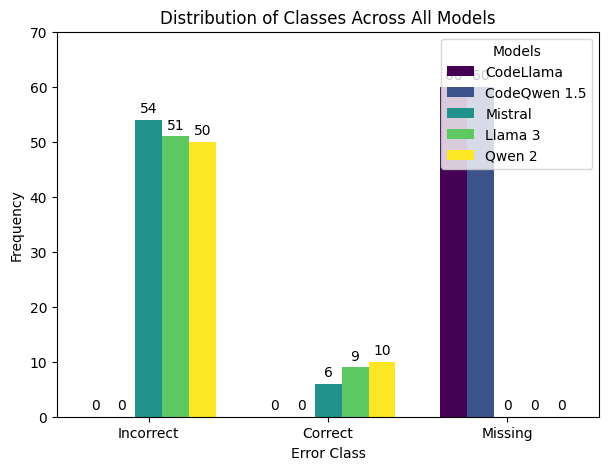

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = ["CodeL", "CodeQ", "Mistral", "Llama", "Qwen"]
labels = ["CodeLlama", "CodeQwen 1.5", "Mistral", "Llama 3 ", "Qwen 2"]

# Define all possible classes
all_classes = [0, 1, 2]

# Initialize a DataFrame to store counts for each model
model_class_counts = pd.DataFrame(index=all_classes)

# Calculate Scenario_Class counts for each model and store them in the DataFrame
for model in models:
    model_df = df[df["ID"].str.contains(model)]
    scenario_class_count = model_df["Transaction_Class"].value_counts().reindex(all_classes, fill_value=0)
    model_class_counts[model] = scenario_class_count

x = np.arange(len(all_classes))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(7, 5))

# Get a colormap and normalize it to the number of models
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(models)))

for i, model in enumerate(models):
    offset = width * multiplier
    rects = ax.bar(x + offset, model_class_counts[model], width, label=labels[i], color=colors[i])
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Error Class")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Classes Across All Models")
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(["Incorrect", "Correct", "Missing"])
ax.legend(title="Models", loc="upper right", ncols=1)
ax.set_ylim(0, model_class_counts.max().max() + 10) 

plt.show()


In [3]:
import pandas as pd

# Load the data
df = pd.read_csv("scenarios_errorgroups.csv")

# Define all possible classes
all_classes = [0, 1, 2,3]
models = ["CodeL", "CodeQ", "Mistral", "Llama", "Qwen"]

# Dictionary to store DataFrames for each model
model_dfs = {}

for model in models:
    # Filter data for the current model
    model_df = df[df["ID"].str.contains(model)]
    
    # Create a pivot table with Scenario_Class and Transaction_Class
    scenario_class_count = model_df.pivot_table(
        index='Scenario_Class',
        columns='Transaction_Class',
        aggfunc='size',
        fill_value=0
    )
    
    # Ensure all classes are represented in the DataFrame
    scenario_class_count = scenario_class_count.reindex(index=all_classes, columns=[0, 1, 2], fill_value=0)
    
    # Store the DataFrame in the dictionary
    model_dfs[model] = scenario_class_count

<Axes: xlabel='Scenario_Class'>

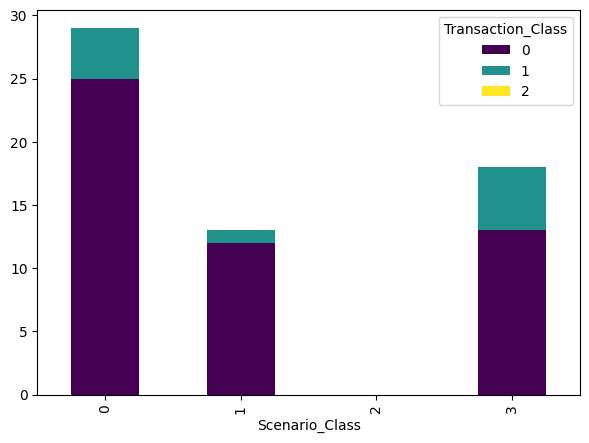

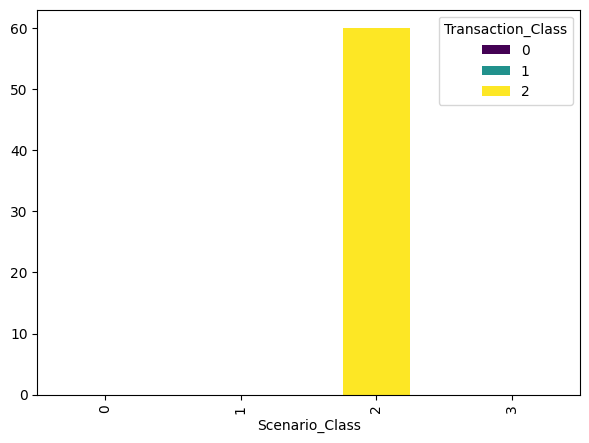

In [4]:
model_dfs['Qwen'].plot(kind='bar', stacked=True, colormap='viridis', figsize=(7, 5))
model_dfs['CodeQ'].plot(kind='bar', stacked=True, colormap='viridis', figsize=(7, 5))


In [5]:
index = df[(df["Scenario_Class"]==1) & (df["Transaction_Class"]==1)]["Transaction"].index
for i in index:
    print(df["ID"][i])
    print(df["Scenario"][i])
    print(df["Transaction"][i],"\n-------------------------------")

Llama-CaR-Mercedes-Benz01
The company uses 1000 EUR in cash to repay current other financial liabilities.
Effect: Negative



2024-07-11 * "Repay current other financial liabilities"
  Liabilities:Current:OtherFinancialLiabilities 1000 EUR
  Assets:Current:CashAndCashEquivalents -1000 EUR 
-------------------------------
Llama-CaR-Mercedes-Benz17
The company uses 2000 EUR in cash to repay current financing liabilities.
Effect: Negative



2024-06-15 * "Repay current financing liabilities"
  Liabilities:Current:FinancingLiabilities -2000 EUR
  Assets:Current:CashAndCashEquivalents 2000 EUR 
-------------------------------
Llama-CaR-SAP14
The company uses 400 EUR in cash to repay current tax liabilities.
Effect: Negative



2024-07-11 * "Repay current tax liabilities"
  Liabilities:Current:TaxLiabilities 400 EUR
  Assets:Current:CashAndCashEquivalents -400 EUR 
-------------------------------
Llama-CaR-SAP18
The company uses 200 EUR in cash to repay current other non-financial liabilitie